In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Loading dataset
df=pd.read_csv("netflix_titles.csv")
print(df.shape)
print()
print(df.describe())
print()
print(df.dtypes)
print()
print(df.isnull().sum())
print()
df.head()

(8807, 12)

       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [17]:
# Extracting year & month from date added which can be a string
df['date_added']=pd.to_datetime(df['date_added'].astype(str).str.strip())
df['year_added']=df['date_added'].dt.year
df['month_added']=df['date_added'].dt.month
# Clean duration column
df['duration_int']=df['duration'].astype(str).str.extract(r'(\d+)').astype('float')
# Extracing primary genre of the movies
df['primary_genre']=df['listed_in'].str.split(',').str[0].str.strip()

In [6]:
# Creating a column whether the movies were recent or older
df['is_recent']= df['year_added'].apply(lambda x: 'Recent' if x>=2019 else 'Older')
# A function which is used to categorize which category does the movie belongs to.
def categorize_rating(rating):
    if rating in ('G', 'TV-G', 'TV-Y', 'TV-Y7'):
        return 'Kids'
    elif rating in ('PG', 'TV-PG', 'PG-13', 'PG-14'):
        return 'Teen'
    else:
        return 'Adult'
# Creating a column by identfying their category
df['audience']=df['rating'].apply(categorize_rating)

type         Movie  TV Show
year_added                 
2008.0         1.0      1.0
2009.0         2.0      0.0
2010.0         1.0      0.0
2011.0        13.0      0.0
2012.0         3.0      0.0
2013.0         6.0      5.0
2014.0        19.0      5.0
2015.0        56.0     26.0
2016.0       253.0    176.0
2017.0       839.0    349.0
2018.0      1237.0    412.0
2019.0      1424.0    592.0
2020.0      1284.0    595.0
2021.0       993.0    505.0


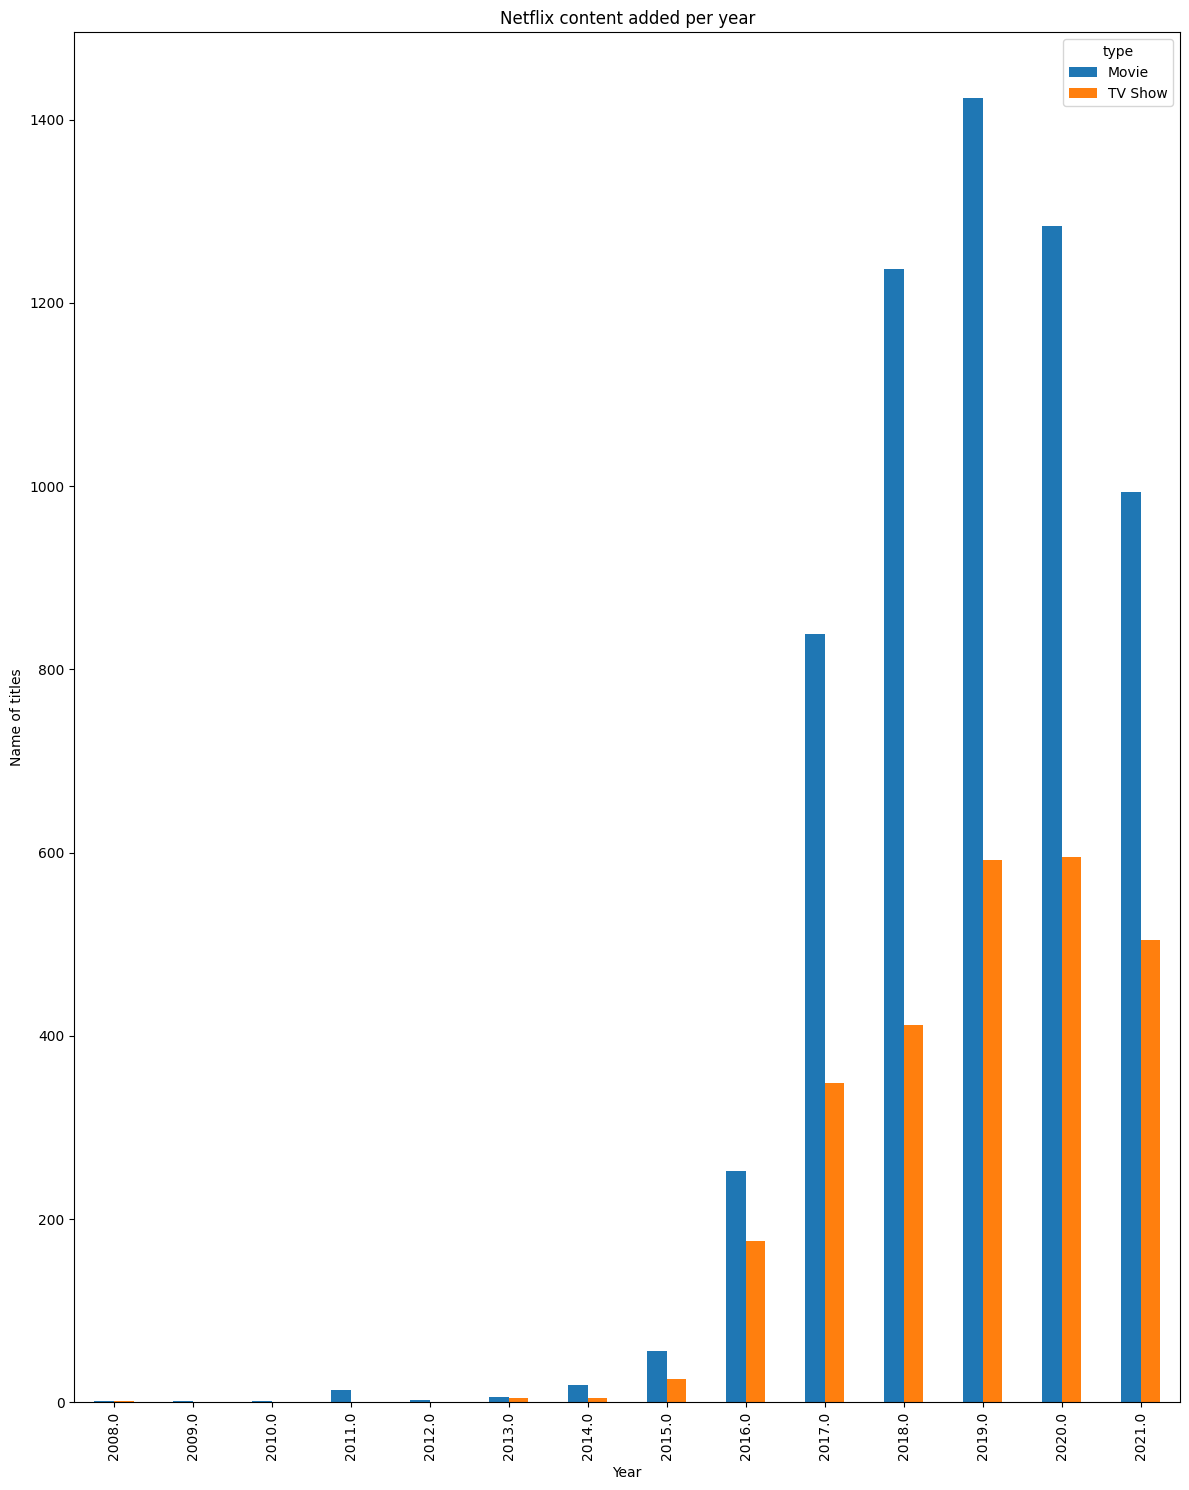

In [9]:
# Content added per year by type
pivot=df.pivot_table(
    index='year_added',
    columns='type',
    values='show_id',
    aggfunc='count'
).fillna(0)
print(pivot)
# Barchart
pivot.plot(kind='bar', figsize=(12,15))
plt.title("Netflix content added per year")
plt.xlabel("Year")
plt.ylabel("Name of titles")
plt.tight_layout()
plt.show()

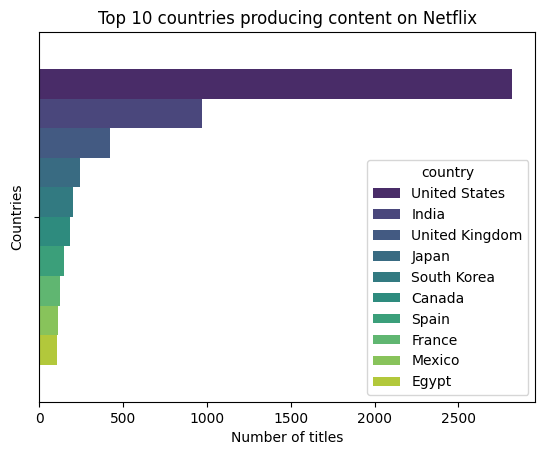

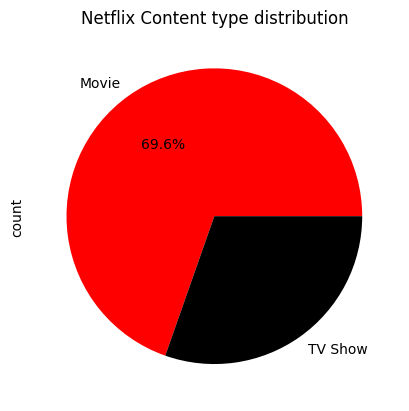

In [23]:
# top 10 countries that are producing content in netflix
top_countries=df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, hue=top_countries.index, palette='viridis')
plt.title("Top 10 countries producing content on Netflix")
plt.xlabel("Number of titles")
plt.ylabel("Countries")
plt.show()

#Movies vs TV shows ratio
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=["red","black"])
plt.title("Netflix Content type distribution")
plt.show()

In [31]:
# Top 5 genres
genre=df['primary_genre'].value_counts().head(5)
print(genre)
print()
# Month in which content is added the most
month=df['month_added'].value_counts().head(1)
print(month)

primary_genre
Dramas                    1600
Comedies                  1210
Action & Adventure         859
Documentaries              829
International TV Shows     774
Name: count, dtype: int64

month_added
7.0    827
Name: count, dtype: int64
